In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import hmean

In [ ]:
# Function to compute the average of the numbers in the string
def compute_average(score_string):
    numbers = list(map(float, score_string.strip("[]").split()))  # Extract numbers and convert to int
    return hmean(numbers)  # Compute the mean

In [15]:
data = pd.read_excel('training_progress.xlsx', sheet_name='ResNet', header=0)
data2 = pd.read_excel('training_progress.xlsx', sheet_name='EfficientNet', header=0)

In [ ]:
# Apply the function to the column
data["Train Label-Harm-Average F1 Score"] = data["Train Label F1 Scores"].apply(compute_average)
data["Val Label-Harm-Average F1 Score"] = data["Val Label F1 Scores"].apply(compute_average)

data.head(5)

,Epoch,Train loss,Train Accuracy,Train Avg F1 Score,Train Label F1 Scores,Val Loss,Val Accuracy,Val Avg F1 Score,Val Label F1 Scores,Notes,Train Label-Harm-Average F1 Score,Val Label-Harm-Average F1 Score
0,6,0.4021,0.4608,0.1079,[0.3408 0.1890 0.1933 0.2775 0.0000],0.3944,0.4605,0.0834,[0.3202 0.2620 0.1391 0.1256 0.0000],"Reset, changed data augmentation",0.000000,0.000000
1,7,0.3653,0.4931,0.1631,[0.5112 0.3180 0.2899 0.3811 0.0000],0.3515,0.4853,0.2475,[0.5845 0.3915 0.4206 0.4114 0.0000],NaN,0.000000,0.000000
2,8,0.3340,0.5167,0.2037,[0.5787 0.3600 0.3616 0.4767 0.0040],0.3801,0.4584,0.2938,[0.5962 0.4817 0.3369 0.5415 0.1255],NaN,0.019278,0.302364
3,9,0.3077,0.5493,0.2507,[0.6228 0.4241 0.4572 0.5827 0.0350],0.2897,0.5800,0.2984,[0.6374 0.3838 0.5650 0.5932 0.1199],NaN,0.137218,0.313080
4,10,0.2829,0.5809,0.2841,[0.6502 0.4666 0.5267 0.6129 0.1385],0.2781,0.5890,0.3188,[0.6349 0.4800 0.5802 0.6438 0.1862,NaN,0.346463,0.406313


In [16]:
# Apply the function to the column
data2["Train Label-Harm-Average F1 Score"] = data2["Train Label F1 Scores"].apply(compute_average)
data2["Val Label-Harm-Average F1 Score"] = data2["Val Label F1 Scores"].apply(compute_average)

data2.head(5)

,Epoch,Train loss,Train Accuracy,Train Avg F1 Score,Train Label F1 Scores,Val Loss,Val Accuracy,Val Avg F1 Score,Val Label F1 Scores,Notes,Train Label-Harm-Average F1 Score,Val Label-Harm-Average F1 Score
0,1,1.2754,0.0157,0.2260,[0.3194 0.2014 0.3460 0.3098 0.1141],1.1268,0.0106,0.2323,[0.2456 0.1386 0.3847 0.3327 0.1135],NaN,0.217595,0.194535
1,2,1.1290,0.1482,0.2527,[0.5147 0.3381 0.4685 0.4380 0.1671],0.9156,0.3353,0.2293,[0.5670 0.3443 0.5166 0.4639 0.2070],NaN,0.326742,0.367907
2,3,1.1089,0.2846,0.2917,[0.6244 0.4028 0.5557 0.5624 0.2413],0.8112,0.2938,0.3213,[0.6421 0.3296 0.5957 0.5105 0.3766],NaN,0.423513,0.459379
3,4,0.9732,0.3298,0.3155,[0.6430 0.4120 0.6010 0.5847 0.2962],0.7134,0.4117,0.3492,[0.6354 0.3826 0.6059 0.6499 0.3939],NaN,0.465868,0.504268
4,5,0.9535,0.3576,0.3310,[0.6462 0.4341 0.6233 0.6107 0.3284],0.6901,0.5062,0.3150,[0.6184 0.4307 0.6627 0.6344 0.4677],NaN,0.493193,0.545716


In [13]:
reset_epochs = [6, 11, 17, 23, 29]

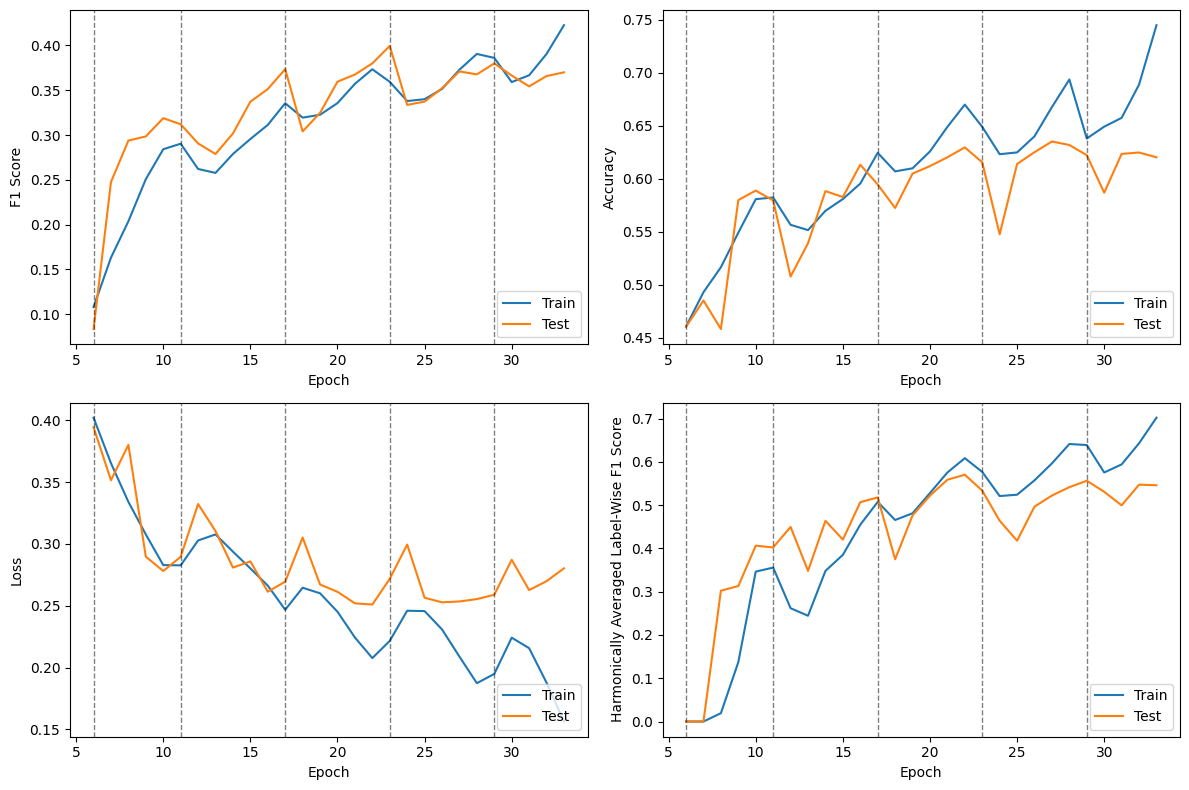

In [14]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))

ax[0,0].plot(data['Epoch'], data['Train Avg F1 Score'], label = 'Train')
ax[0,0].plot(data['Epoch'], data['Val Avg F1 Score'], label = 'Test')
ax[0,0].set_xlabel('Epoch')
ax[0,0].set_ylabel('F1 Score')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(data['Epoch'], data['Train Accuracy'], label = 'Train')
ax[0,1].plot(data['Epoch'], data['Val Accuracy'], label = 'Test')
ax[0,1].set_xlabel('Epoch')
ax[0,1].set_ylabel('Accuracy')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(data['Epoch'], data['Train loss'], label = 'Train')
ax[1,0].plot(data['Epoch'], data['Val Loss'], label = 'Test')
ax[1,0].set_xlabel('Epoch')
ax[1,0].set_ylabel('Loss')
ax[1,0].legend(loc='lower right')

ax[1,1].plot(data['Epoch'], data['Train Label-Harm-Average F1 Score'], label = 'Train')
ax[1,1].plot(data['Epoch'], data['Val Label-Harm-Average F1 Score'], label = 'Test')
ax[1,1].set_xlabel('Epoch')
ax[1,1].set_ylabel('Harmonically Averaged Label-Wise F1 Score')
ax[1,1].legend(loc='lower right')


for epoch in reset_epochs: 
    ax[0,0].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[0,1].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[1,0].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[1,1].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)

fig.tight_layout()

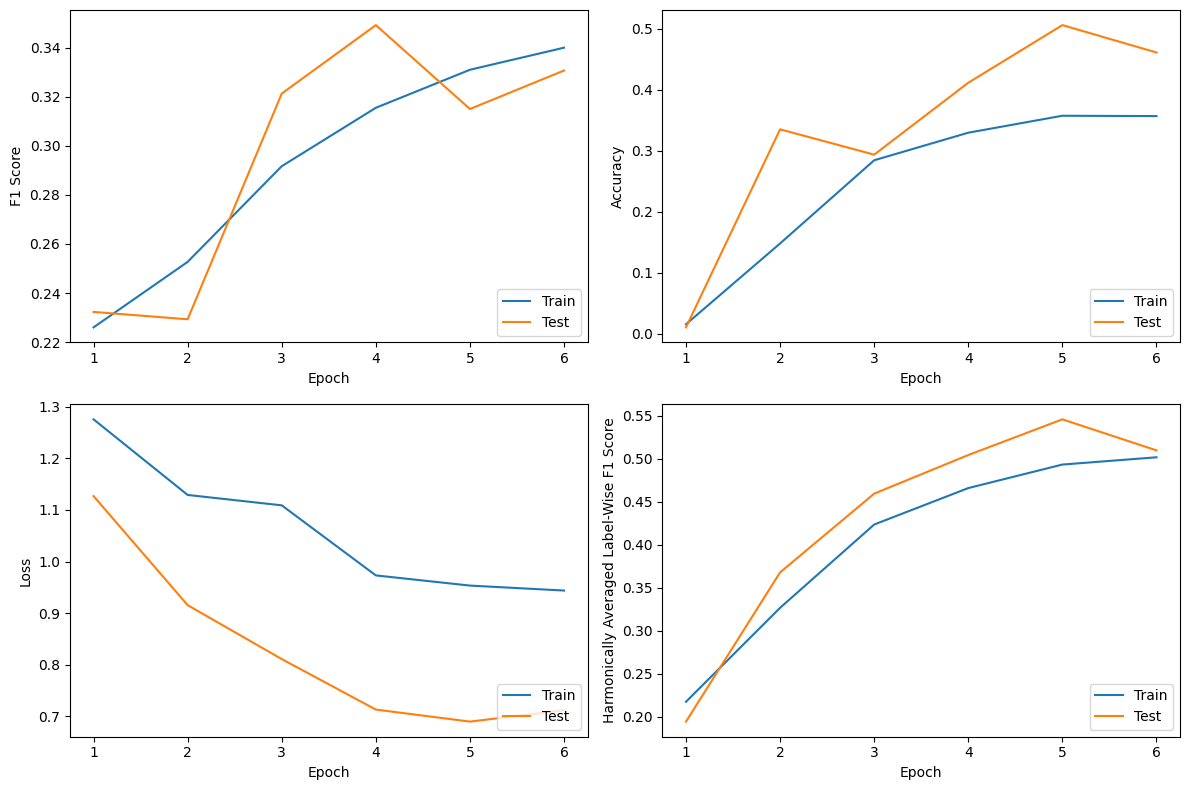

In [17]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))

ax[0,0].plot(data2['Epoch'], data2['Train Avg F1 Score'], label = 'Train')
ax[0,0].plot(data2['Epoch'], data2['Val Avg F1 Score'], label = 'Test')
ax[0,0].set_xlabel('Epoch')
ax[0,0].set_ylabel('F1 Score')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(data2['Epoch'], data2['Train Accuracy'], label = 'Train')
ax[0,1].plot(data2['Epoch'], data2['Val Accuracy'], label = 'Test')
ax[0,1].set_xlabel('Epoch')
ax[0,1].set_ylabel('Accuracy')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(data2['Epoch'], data2['Train loss'], label = 'Train')
ax[1,0].plot(data2['Epoch'], data2['Val Loss'], label = 'Test')
ax[1,0].set_xlabel('Epoch')
ax[1,0].set_ylabel('Loss')
ax[1,0].legend(loc='lower right')

ax[1,1].plot(data2['Epoch'], data2['Train Label-Harm-Average F1 Score'], label = 'Train')
ax[1,1].plot(data2['Epoch'], data2['Val Label-Harm-Average F1 Score'], label = 'Test')
ax[1,1].set_xlabel('Epoch')
ax[1,1].set_ylabel('Harmonically Averaged Label-Wise F1 Score')
ax[1,1].legend(loc='lower right')

fig.tight_layout()